# Using FFTs to remove the seasonal cycle

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/seasonal_cycle_filtering.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-26*

## Learning objectives

- Use the FFT to identify the dominant low-frequency power (the seasonal cycle and its harmonics) in a daily climate time series.
- Construct low-pass and high-pass versions of a signal by zeroing the appropriate Fourier coefficients and inverting with `np.fft.ifft`.
- Practice **two methods** of removing a seasonal cycle: (A) low-pass-filter the daily climatology, then subtract; (B) high-pass-filter the full time series directly. Compare them quantitatively.
- Verify Parseval's theorem and the symmetric layout of `np.fft.fft` output.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Figure defaults for this notebook.
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (6.0, 4.0)

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print(f"IN_COLAB = {IN_COLAB}")

IN_COLAB = False


## Load the daily Z500 series

We use ~34 years of daily 500-hPa geopotential height at 45°N, 330°E.

In [2]:
if IN_COLAB:
    !wget -q https://raw.githubusercontent.com/eabarnes1010/course_objective_analysis/main/data/z500_daily_45N_330E.npz
    filename = "z500_daily_45N_330E.npz"
else:
    filename = "../data/z500_daily_45N_330E.npz"

da = np.load(filename)
X = da["X"]
TIME = da["TIME"]
print(f"X.shape = {X.shape}")

X.shape = (12297,)


Plot the full and anomalous (mean-removed) time series.

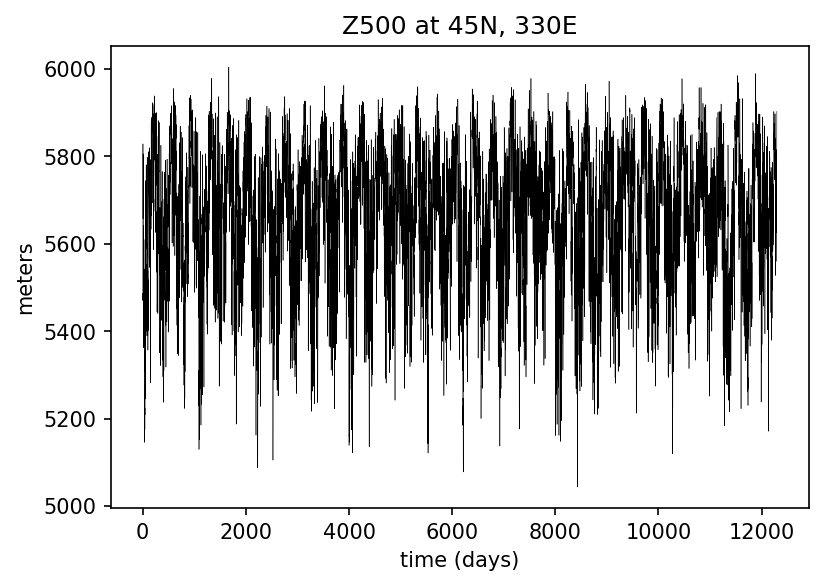

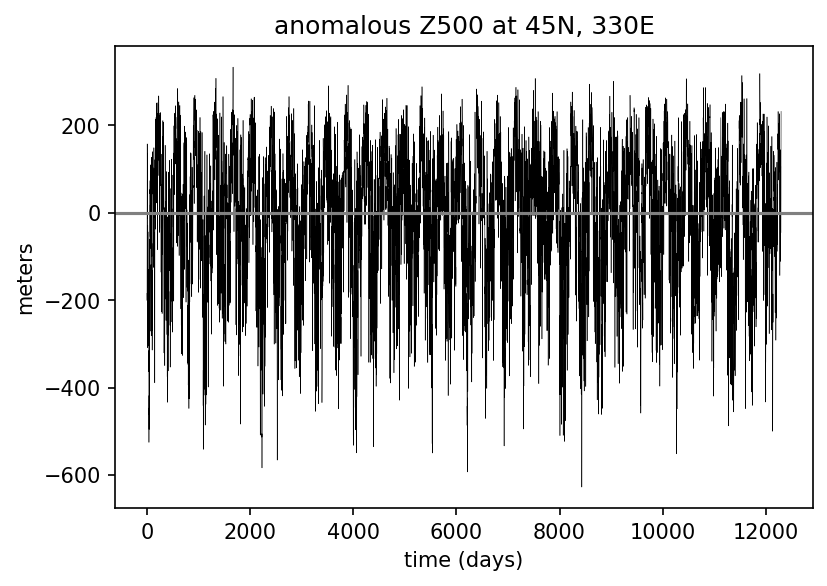

In [3]:
plt.figure()
plt.plot(np.arange(X.size), X, "-k", linewidth=0.25)
plt.ylabel("meters")
plt.xlabel("time (days)")
plt.title("Z500 at 45N, 330E")
plt.show()

plt.figure()
plt.plot(np.arange(X.size), X - np.mean(X), "-k", linewidth=0.25)
plt.axhline(y=0, color="gray")
plt.ylabel("meters")
plt.xlabel("time (days)")
plt.title("anomalous Z500 at 45N, 330E")
plt.show()

# Method A: filter the climatological seasonal cycle

## Build the daily climatology

For each (month, day) pair in the calendar, average across all years. The result is a 365- (or 366-) day climatological annual cycle with all its daily wiggles.

In [4]:
TIME_climate = np.vstack(sorted({tuple(row) for row in TIME[:, 2:4]}))
TIME_climate = TIME_climate[np.lexsort((TIME_climate[:, 1], TIME_climate[:, 0])), :]

days_in_year = TIME_climate.shape[0]
Yclim = np.full(days_in_year, np.nan)
for iday in range(days_in_year):
    month, day = TIME_climate[iday, 0], TIME_climate[iday, 1]
    t = np.where((TIME[:, 2] == month) & (TIME[:, 3] == day))
    Yclim[iday] = np.nanmean(X[t])

Yclim_anom = Yclim - np.mean(Yclim)

Plot the climatology and its anomaly.

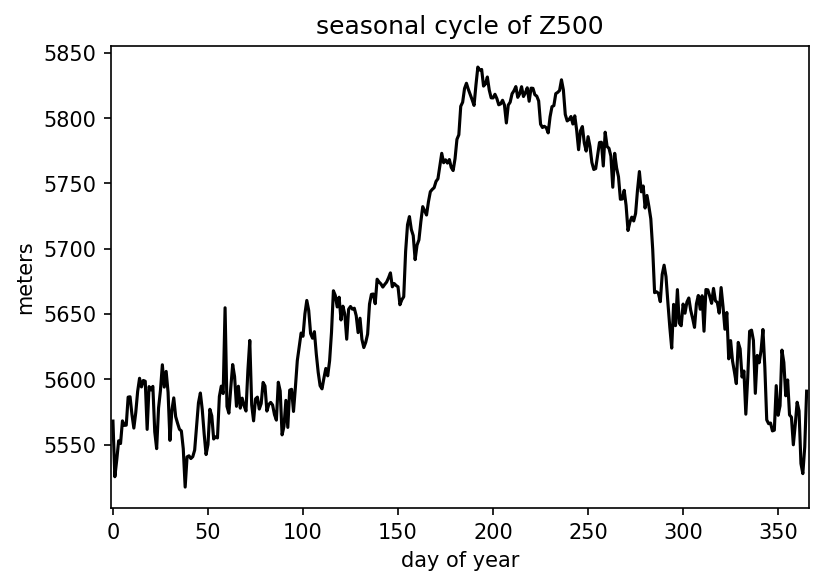

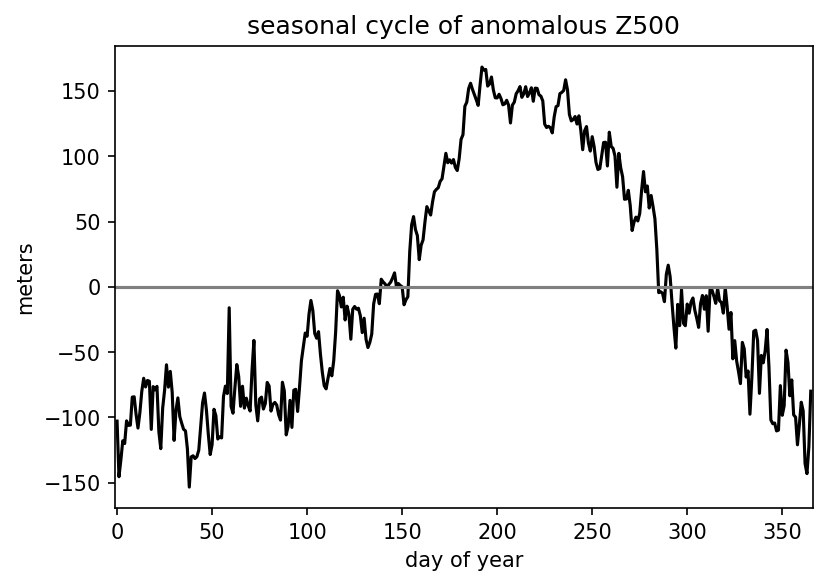

In [5]:
plt.figure()
plt.plot(np.arange(Yclim.size), Yclim, "-k")
plt.ylabel("meters")
plt.xlabel("day of year")
plt.xlim(-1, 366)
plt.title("seasonal cycle of Z500")
plt.show()

plt.figure()
plt.plot(np.arange(Yclim_anom.size), Yclim_anom, "-k")
plt.ylabel("meters")
plt.xlabel("day of year")
plt.xlim(-1, 366)
plt.title("seasonal cycle of anomalous Z500")
plt.axhline(y=0, color="gray")
plt.show()

## FFT of the climatology

In [6]:
Z = np.fft.fft(Yclim_anom)
Yfft = Z / Yclim_anom.size

Plot the raw FFT output. Note the symmetric layout: the first index is the mean, and the lowest non-trivial frequency appears at both index 1 and the very last index.

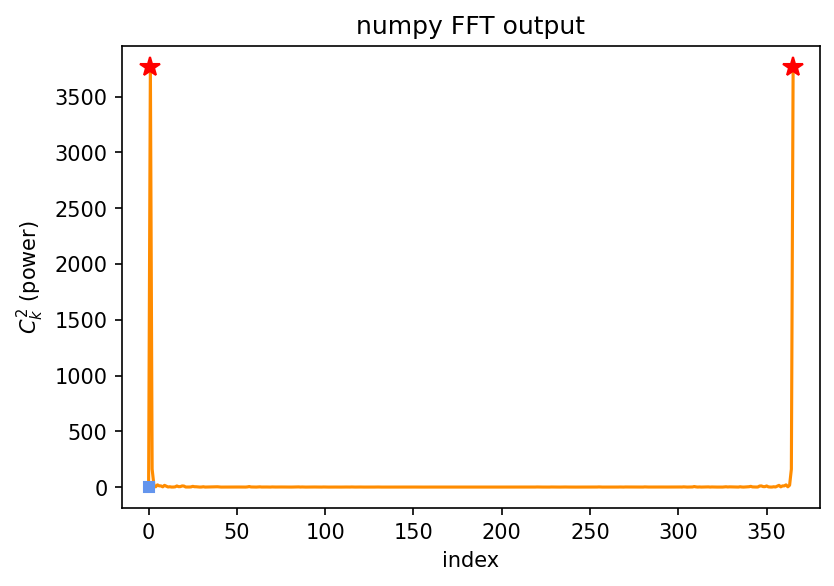

In [7]:
plt.figure()
plt.plot(np.arange(Yfft.size), np.abs(Yfft) ** 2, color="darkorange")
plt.plot(0, np.abs(Yfft[0]) ** 2, "s", color="cornflowerblue", markersize=5)
plt.plot(1, np.abs(Yfft[1]) ** 2, "*r", markersize=10)
plt.plot(Yfft.size - 1, np.abs(Yfft[-1]) ** 2, "*r", markersize=10)
plt.xlabel("index")
plt.ylabel(r"$C_k^2$ (power)")
plt.title("numpy FFT output")
plt.xlim(-15, 365 + 15)
plt.show()

Combine the symmetric halves and plot the (one-sided) power spectrum.

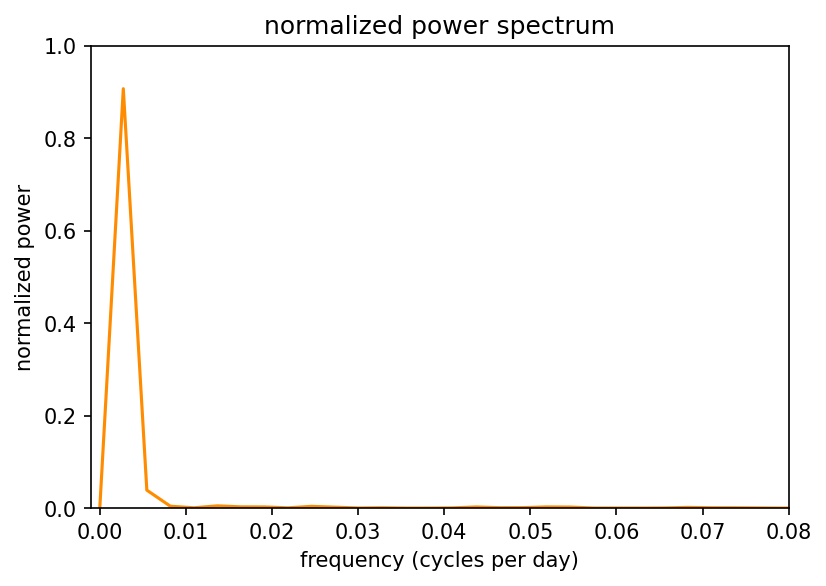

In [8]:
freq = np.arange(0, Yclim_anom.size / 2 + 1) / float(Yclim_anom.size)
Ck2 = 2.0 * np.abs(Yfft[: Yclim_anom.size // 2 + 1]) ** 2

plt.figure()
plt.plot(freq, Ck2 / np.sum(Ck2), "-", color="darkorange", label="original spectrum")
plt.ylabel("normalized power")
plt.xlabel("frequency (cycles per day)")
plt.xlim(-0.001, 0.08)
plt.ylim(0, 1.0)
plt.title("normalized power spectrum")
plt.show()

Almost all the power lives at the lowest frequencies — that is the seasonal cycle plus its harmonics.

### Check Parseval's theorem

In [9]:
var_actual = np.var(Yclim_anom)
a = Yfft[: Yclim_anom.size // 2 + 1]
var_spectrum = np.real(2 * np.sum(a[1:] * np.conj(a[1:])))

print(f"variance actual   = {var_actual}")
print(f"variance spectrum = {var_spectrum}")

variance actual   = 8294.28473719378
variance spectrum = 8294.454547617406


## Pick a cutoff and visualise the low-pass region

Keep `numHarm = 3` harmonics (the mean plus the first two non-zero frequencies).

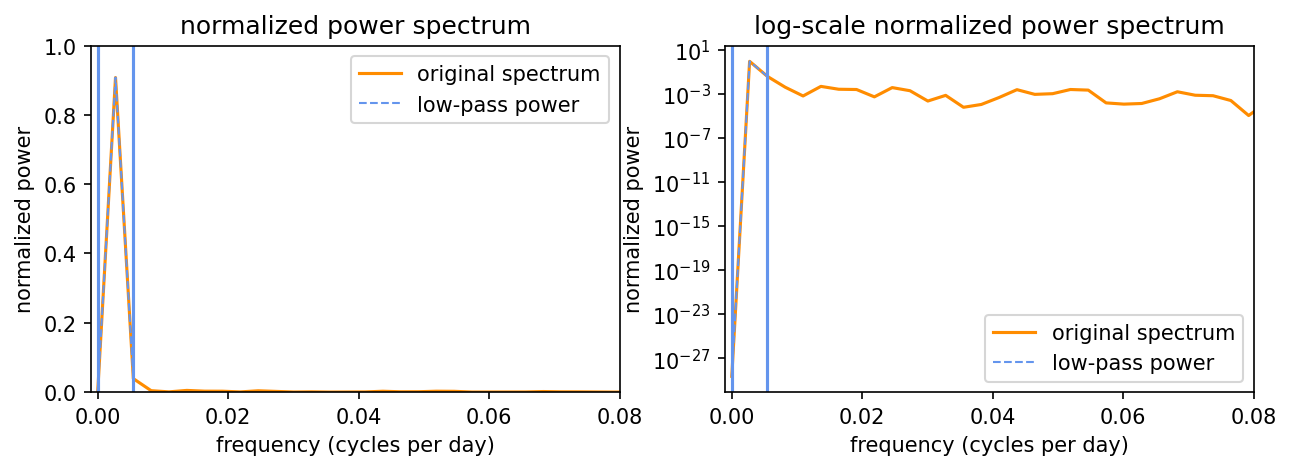

In [10]:
numHarm = 3

plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(freq, Ck2 / np.sum(Ck2), "-", color="darkorange", label="original spectrum")
plt.ylabel("normalized power")
plt.xlabel("frequency (cycles per day)")
plt.xlim(-0.001, 0.08)
plt.ylim(0, 1.0)
plt.title("normalized power spectrum")
plt.axvline(x=0, color="cornflowerblue", linewidth=1.5)
plt.axvline(x=freq[numHarm - 1], color="cornflowerblue", linewidth=1.5)
A = Ck2 / np.sum(Ck2)
A[numHarm:] = 0.0
plt.plot(
    freq[:numHarm],
    A[:numHarm],
    "--",
    color="cornflowerblue",
    linewidth=1,
    label="low-pass power",
)
plt.yscale("linear")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(freq, Ck2 / np.sum(Ck2), "-", color="darkorange", label="original spectrum")
plt.ylabel("normalized power")
plt.xlabel("frequency (cycles per day)")
plt.xlim(-0.001, 0.08)
plt.title("log-scale normalized power spectrum")
plt.axvline(x=0, color="cornflowerblue", linewidth=1.5)
plt.axvline(x=freq[numHarm - 1], color="cornflowerblue", linewidth=1.5)
A = Ck2 / np.sum(Ck2)
A[numHarm:] = 0.0
plt.plot(
    freq[:numHarm],
    A[:numHarm],
    "--",
    color="cornflowerblue",
    linewidth=1,
    label="low-pass power",
)
plt.yscale("log")
plt.legend()
plt.show()

## Construct low-pass and high-pass versions

Zero the appropriate coefficients on **both** sides of the symmetric FFT, then invert.

In [11]:
Zlow = np.copy(Z)
Zlow[numHarm : -(numHarm - 1)] = 0.0
X_lowpass = np.real(np.fft.ifft(Zlow))

Zhigh = np.copy(Z)
Zhigh[:numHarm] = 0.0
Zhigh[-(numHarm - 1) :] = 0.0
X_highpass = np.real(np.fft.ifft(Zhigh))

## Visualise the components

Overlay the raw climatology, the high-pass residual, the low-pass smoothed seasonal cycle, and a running-mean version for comparison. Notice that high-pass + low-pass = original.

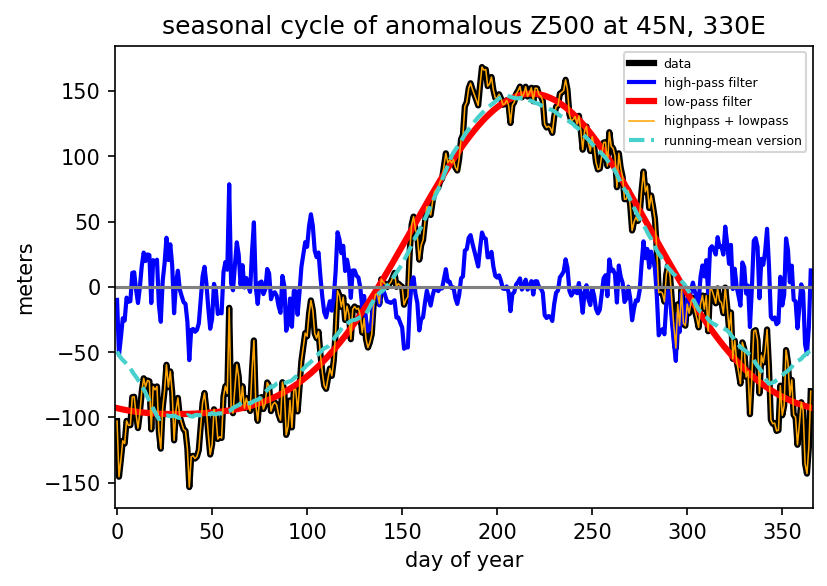

In [12]:
plt.figure()
plt.plot(np.arange(Yclim_anom.size), Yclim_anom, "-k", linewidth=3, label="data")
plt.plot(
    np.arange(Yclim_anom.size), X_highpass, "-b", linewidth=2, label="high-pass filter"
)
plt.plot(
    np.arange(Yclim_anom.size), X_lowpass, "-r", linewidth=3, label="low-pass filter"
)
plt.plot(
    np.arange(Yclim_anom.size),
    X_lowpass + X_highpass,
    "-",
    color="orange",
    linewidth=0.75,
    label="highpass + lowpass",
)

N = 45
Yclim_runmean = np.convolve(Yclim_anom, np.ones(N) / N, mode="same")
plt.plot(
    np.arange(Yclim_anom.size),
    Yclim_runmean,
    "--",
    color="mediumturquoise",
    linewidth=2.0,
    label="running-mean version",
)

plt.axhline(y=0, color="gray")
plt.legend(fontsize=6)
plt.ylabel("meters")
plt.xlabel("day of year")
plt.xlim(-1, 366)
plt.title("seasonal cycle of anomalous Z500 at 45N, 330E")
plt.show()

## Remove the seasonal cycle from the full series

For every (month, day) pair, subtract the low-pass climatological value from the corresponding daily observations.

In [13]:
X_no_sc = np.zeros_like(X)
for iday in range(days_in_year):
    month, day = TIME_climate[iday, 0], TIME_climate[iday, 1]
    t = np.where((TIME[:, 2] == month) & (TIME[:, 3] == day))
    X_no_sc[t] = (X[t] - np.mean(X)) - X_lowpass[iday]

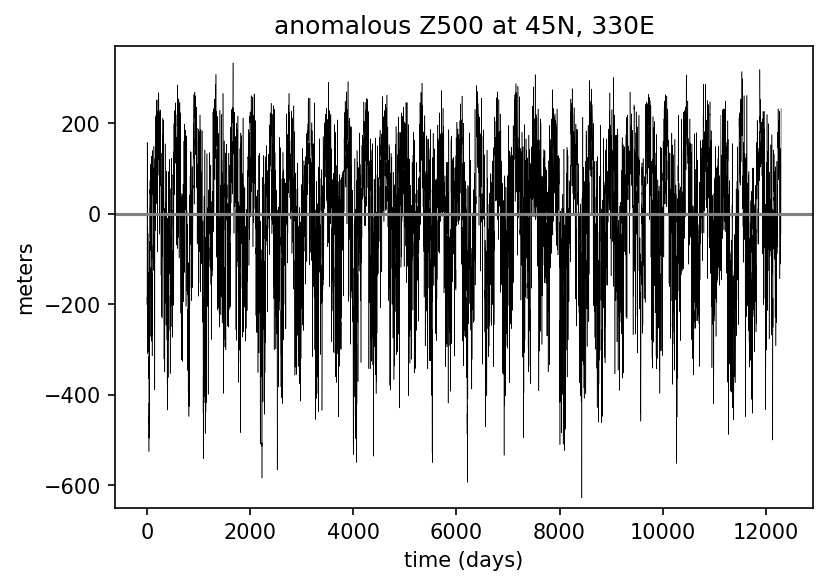

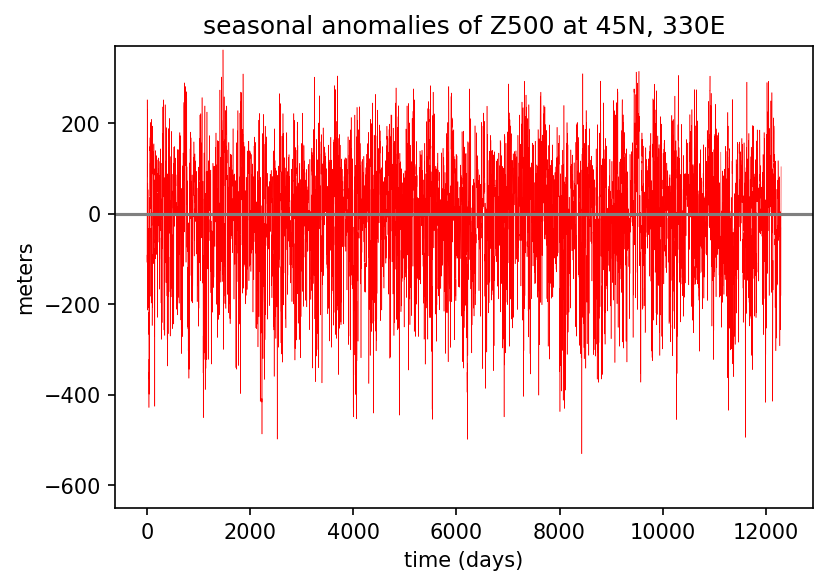

In [14]:
plt.figure()
plt.plot(np.arange(X.size), X - np.mean(X), "-k", linewidth=0.25)
plt.axhline(y=0, color="gray")
plt.ylabel("meters")
plt.xlabel("time (days)")
plt.title("anomalous Z500 at 45N, 330E")
plt.ylim(-650, 370)
plt.show()

plt.figure()
plt.plot(np.arange(X.size), X_no_sc, "-r", linewidth=0.25)
plt.axhline(y=0, color="gray")
plt.ylabel("meters")
plt.xlabel("time (days)")
plt.title("seasonal anomalies of Z500 at 45N, 330E")
plt.ylim(-650, 370)
plt.show()

# Method B: high-pass the full time series directly

Instead of building a climatology, run the FFT on the entire de-meaned time series and zero out the low frequencies.

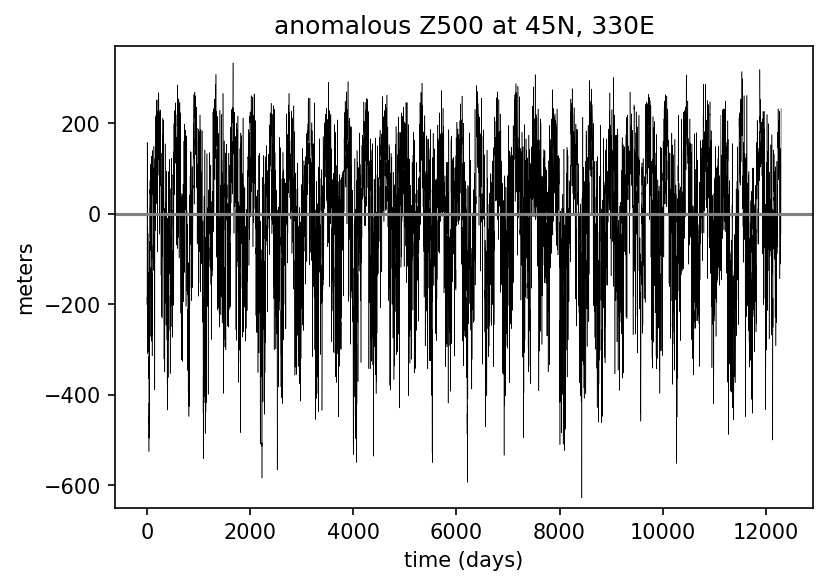

In [15]:
X_anom = X - np.mean(X)

plt.figure()
plt.plot(np.arange(X_anom.size), X_anom, "-k", linewidth=0.25)
plt.axhline(y=0, color="gray")
plt.ylabel("meters")
plt.xlabel("time (days)")
plt.title("anomalous Z500 at 45N, 330E")
plt.ylim(-650, 370)
plt.show()

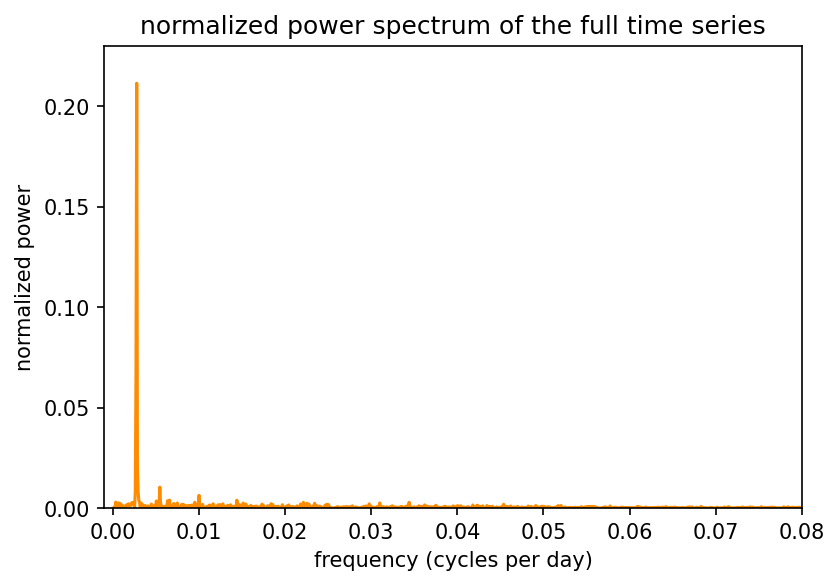

In [16]:
Z = np.fft.fft(X_anom)
Yfft = Z / X_anom.size

freq = np.arange(0, X_anom.size / 2) / float(X_anom.size)
Ck2 = 2.0 * np.abs(Yfft[: X_anom.size // 2 + 1]) ** 2

plt.figure()
plt.plot(
    freq,
    Ck2[: freq.size] / np.sum(Ck2),
    "-",
    color="darkorange",
    label="original spectrum",
)
plt.ylabel("normalized power")
plt.xlabel("frequency (cycles per day)")
plt.xlim(-0.001, 0.08)
plt.ylim(0, 0.23)
plt.title("normalized power spectrum of the full time series")
plt.show()

Choose the harmonic index closest to one cycle per 182.5 days — this captures the annual and semi-annual signals. Zero the corresponding low-frequency coefficients on both sides.

In [17]:
numHarm = int(np.argmin(np.abs(freq - 1 / 182.5)))

Zlow = np.copy(Z)
Zlow[numHarm : -(numHarm - 1)] = 0.0
X_lowpass = np.real(np.fft.ifft(Zlow))

Zhigh = np.copy(Z)
Zhigh[:numHarm] = 0.0
Zhigh[-(numHarm - 1) :] = 0.0
X_highpass_full = np.real(np.fft.ifft(Zhigh))

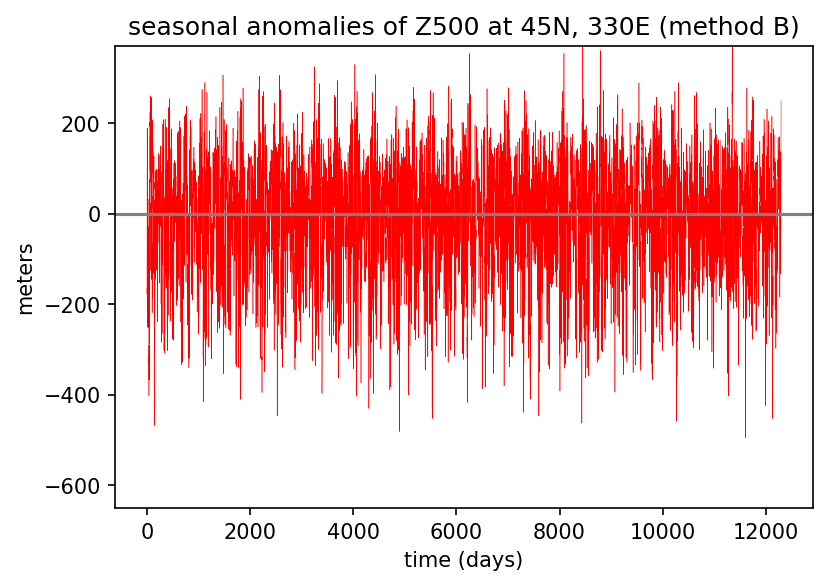

In [18]:
plt.figure()
plt.plot(np.arange(X_highpass_full.size), X_highpass_full, "-r", linewidth=0.25)
plt.axhline(y=0, color="gray")
plt.ylabel("meters")
plt.xlabel("time (days)")
plt.title("seasonal anomalies of Z500 at 45N, 330E (method B)")
plt.ylim(-650, 370)
plt.show()

# Compare the two methods

Method A and Method B both produce de-seasonalised time series. To quantify how similar they are, take the correlation.

In [19]:
corr = np.corrcoef(X_highpass_full, X_no_sc)[0, 1]
print(f"correlation between the two methods: {corr:.3f}")

correlation between the two methods: 0.941


## Take-home points

- The seasonal cycle and its first few harmonics carry the bulk of the variance in daily climate data. FFT-based filtering lets you isolate them cleanly.
- The output of `np.fft.fft` is symmetric — when zeroing out coefficients you must zero **both sides** for a real-valued inverse.
- Method A (smooth the daily climatology, subtract from observations) is usually preferred because the climatology averages out noise before doing the spectral decomposition. Method B works directly on the long time series and gives a very similar answer when you have a lot of data.